In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Task1

In [7]:
fx = pd.read_csv('data_safe_copy.csv',parse_dates=['Date']).set_index('Date')
fx.head()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
Date,,,,,,,,,,,
2025-01-02,1.02661,1.23826,0.240270,4.16199,157.4610,0.62033,0.55966,1.44067,0.91210,4.27274,5.15363
2025-01-03,1.03062,1.24267,0.241453,4.14160,157.3420,0.62176,0.56089,1.44467,0.90891,4.26841,5.14664
2025-01-06,1.03900,1.25188,0.244290,4.09350,157.6200,0.62427,0.56402,1.43330,0.90478,4.25315,5.12457
2025-01-07,1.03426,1.24771,0.242804,4.11855,158.0405,0.62326,0.56331,1.43683,0.90937,4.25965,5.13875
2025-01-08,1.03185,1.23638,0.241377,4.14290,158.3085,0.62132,0.56058,1.43758,0.91101,4.27485,5.12220


In [9]:
fx.tail()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
Date,,,,,,,,,,,
2026-01-26,1.18777,1.36768,0.282362,3.54155,154.1550,0.69100,0.59697,1.37115,0.77720,4.20655,4.84370
2026-01-27,1.20426,1.38461,0.286789,3.48689,152.3020,0.70092,0.60433,1.35758,0.76114,4.19912,4.82798
2026-01-28,1.19562,1.38024,0.284316,3.51721,153.4235,0.70384,0.60594,1.35621,0.76859,4.20524,4.85459
2026-01-29,1.19695,1.38095,0.284600,3.51370,153.0050,0.70497,0.60751,1.34872,0.76476,4.20572,4.85224
2026-01-30,1.18534,1.36839,0.281465,3.55284,154.7785,0.69637,0.60212,1.36162,0.77302,4.21132,4.86167


# Task2

In [14]:
pair_ends_usd = 'EURUSD'
pair_starts_usd = 'USDJPY'

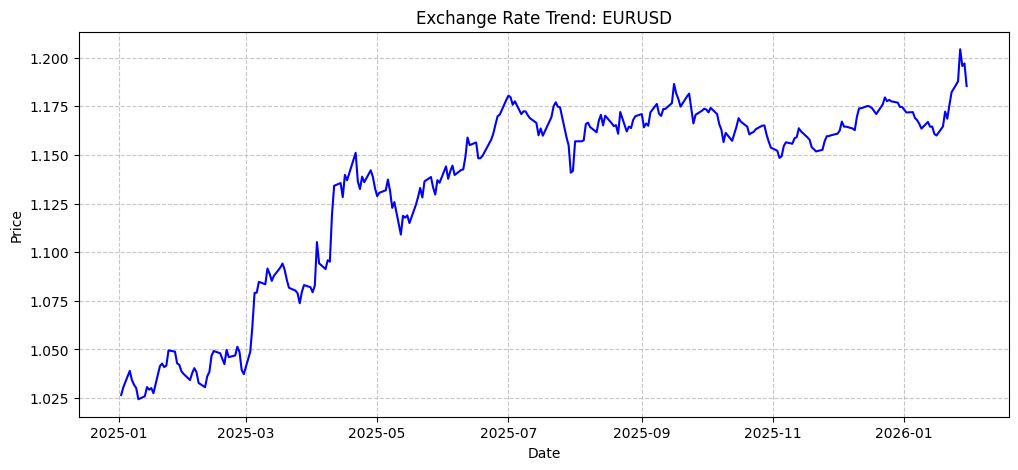

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(fx.index, fx[pair_ends_usd], color='blue')
plt.title(f'Exchange Rate Trend: {pair_ends_usd}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

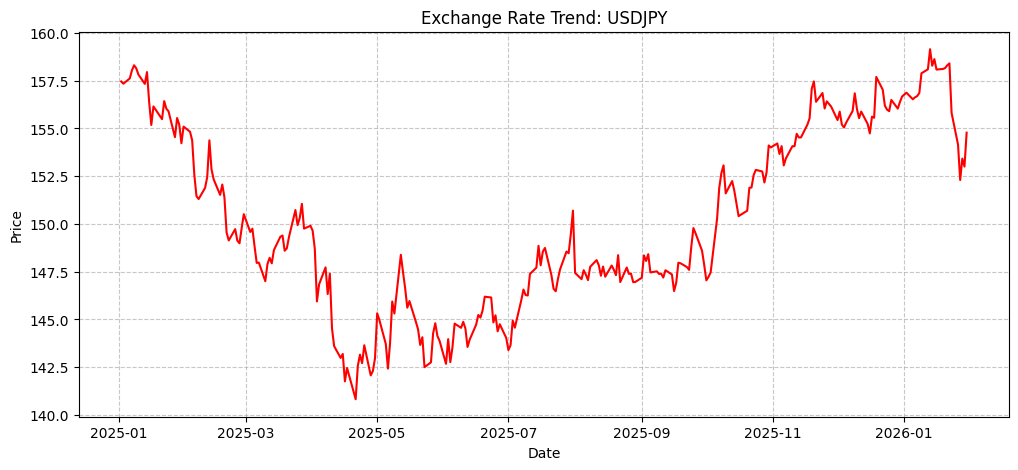

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(fx.index,fx[pair_starts_usd], color='red')
plt.title(f'Exchange Rate Trend: {pair_starts_usd}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

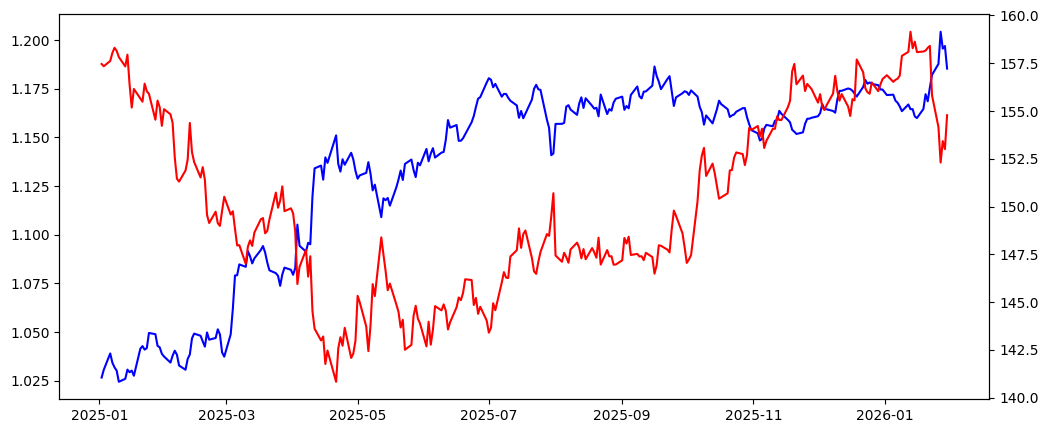

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(fx.index, fx[pair_ends_usd], color='blue')
ax2 = ax1.twinx()
ax2.plot(fx.index,fx[pair_starts_usd], color='red')
plt.show()

# Task3

In [27]:
fx['EURUSD_7d_Mean'] = fx['EURUSD'].rolling(window = 7).mean()
fx['USDJPY_7d_Mean'] = fx['USDJPY'].rolling(window = 7).mean()

In [29]:
fx['EURUSD_7d_Mean'][:10] ,fx['USDJPY_7d_Mean'][:10]

(Date
 2025-01-02         NaN
 2025-01-03         NaN
 2025-01-06         NaN
 2025-01-07         NaN
 2025-01-08         NaN
 2025-01-09         NaN
 2025-01-10    1.030991
 2025-01-13    1.030900
 2025-01-14    1.030911
 2025-01-15    1.029531
 Name: EURUSD_7d_Mean, dtype: float64,
 Date
 2025-01-02           NaN
 2025-01-03           NaN
 2025-01-06           NaN
 2025-01-07           NaN
 2025-01-08           NaN
 2025-01-09           NaN
 2025-01-10    157.820571
 2025-01-13    157.802286
 2025-01-14    157.889214
 2025-01-15    157.712929
 Name: USDJPY_7d_Mean, dtype: float64)

# Task4

In [30]:
selected_pair = "USDCAD"
fx['baseline_pred'] = fx[selected_pair].shift(1)
fx['absolute_error'] = (fx[selected_pair] - fx['baseline_pred']).abs()
fx['absolute_error'].mean()

np.float64(0.0035983870967741883)

In [31]:
is_valid = fx['absolute_error'].notna().sum() == len(fx) -1
is_valid

np.True_

# Task5

In [32]:
report = {
    "chosen_pairs": ["EURUSD", "USDJPY"],
    "rolling_window_size": 7,
    "baseline_error_mean": fx['absolute_error'].mean(),
    "date_range": {
        "start": fx.index.min().strftime('%Y-%m-%d'),
        "end": fx.index.max().strftime('%Y-%m-%d')
    }
}

In [33]:
report['rolling_window_size'] == 7

True

In [34]:
report

{'chosen_pairs': ['EURUSD', 'USDJPY'],
 'rolling_window_size': 7,
 'baseline_error_mean': np.float64(0.0035983870967741883),
 'date_range': {'start': '2025-01-02', 'end': '2026-01-30'}}